## IMPORT FUNCTIONS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import math
import lightgbm as lgb
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix

## PRE PROCESSING

In [2]:
df = pd.read_parquet("US_accidents_dataset.parquet")
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code"], inplace=True)

df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time']   = pd.to_datetime(df['End_Time'],   format='mixed')
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour']  = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    if (m == 12 and d >= 24) or (m == 1 and d <= 2): return 1
    if m == 11 and d >= 22:      return 1
    if m == 7  and d == 4:       return 1
    if m == 5  and d >= 25:      return 1
    if m == 9  and d <= 7:       return 1
    if m == 10 and d == 31:      return 1
    if m == 2  and 7 <= d <= 10: return 1
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)
df.drop(columns=['Wind_Chill(F)', 'Country'], inplace=True)

def time_of_day(h):
    if 6  <= h < 9:  return 0  # morning_rush
    if 9  <= h < 16: return 1  # daytime
    if 16 <= h < 19: return 2  # evening_rush
    if 19 <= h < 23: return 3  # evening
    return 4                   # night

df['time_of_day'] = df['hour'].apply(time_of_day)

# Encoding ciclico mese
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df.drop(columns=['hour', 'month'], inplace=True)

def group_weather(w):
    if pd.isna(w): return 'Unknown'
    w = str(w).lower()
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm', 'tornado', 'funnel']): return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing', 'hail']): return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain', 'drizzle', 'shower']): return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):                                    return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):                 return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):     return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):                                 return 'Clear'
    return 'Other'

def weather_intensity(w):
    if pd.isna(w): return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']): return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):         return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):      return 1
    return 0

df['Weather_Group']     = df['Weather_Condition'].apply(group_weather)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)
df.drop(columns=['Weather_Condition'], inplace=True)

def classify_street(name):
    if pd.isna(name): return 'Unknown'
    name_upper = str(name).upper().strip()
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    if re.match(r'^I-\d+', name_clean):          return 'Interstate'
    if re.match(r'^US-\d+', name_clean):         return 'US_Route'
    if re.match(r'^[A-Z]{2}-\d+', name_clean):  return 'State_Route'
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']): return 'Freeway_Expressway'
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):    return 'Highway'
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):   return 'Parkway'
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']): return 'Boulevard'
    if any(x in name_clean for x in [' AVE', 'AVENUE']):    return 'Avenue'
    if any(x in name_clean for x in [' RD', ' ROAD']):      return 'Road'
    if any(x in name_clean for x in [' ST', ' STREET']):    return 'Street'
    if any(x in name_clean for x in [' DR', ' DRIVE']):     return 'Drive'
    if any(x in name_clean for x in [' LN', ' LANE']):      return 'Lane'
    if any(x in name_clean for x in [' TRL', ' TRAIL']):    return 'Trail'
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']): return 'Local'
    return 'Other'

df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)

df.drop(columns=['ID'], inplace=True)
df['desc_length']         = df['Description'].str.len()
df['lanes_blocked']       = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)
df['mentions_closed']     = df['Description'].str.contains(r'closed|closure',         case=False, na=False).astype(int)
df['mentions_blocked']    = df['Description'].str.contains(r'blocked',                case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic',     case=False, na=False).astype(int)
df['mentions_slow']       = df['Description'].str.contains(r'slow traffic',           case=False, na=False).astype(int)
df['mentions_delay']      = df['Description'].str.contains(r'delay|expect delay',     case=False, na=False).astype(int)
df['mentions_shoulder']   = df['Description'].str.contains(r'shoulder',               case=False, na=False).astype(int)
df['unconfirmed']         = df['Description'].str.contains(r'unconfirmed',            case=False, na=False).astype(int)
df['multiple_vehicles']   = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)
df['desc_highway']        = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)
df['drive_caution']       = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed']     = df['Description'].str.contains(r'crash|accident',         case=False, na=False).astype(int)
df.drop(columns=['Description'], inplace=True)

bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal']
df[bool_cols] = df[bool_cols].astype(int)

df['Sunrise_Sunset'] = (df['Sunrise_Sunset'] == 'Day').astype(int)
df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'Calm': -1, 'VAR': -1, 'Variable': -1
}
df['Wind_Deg']  = df['Wind_Direction'].map(direction_map)
df['Wind_Sin']  = np.where(df['Wind_Deg'] >= 0, np.sin(np.radians(df['Wind_Deg'])), 0)
df['Wind_Cos']  = np.where(df['Wind_Deg'] >= 0, np.cos(np.radians(df['Wind_Deg'])), 0)
df['Wind_Calm'] = (df['Wind_Deg'] < 0).astype(int)
df.drop(columns=['Wind_Direction', 'Wind_Deg'], inplace=True)

source_map = {'Source1': 0, 'Source2': 1, 'Source3': 2}
df['Source'] = df['Source'].map(source_map)

df.drop(columns=[
    'Roundabout', 'Bump', 'Traffic_Calming', 'No_Exit',
    'unconfirmed', 'Amenity', 'Railway', 'Give_Way',
    'multiple_vehicles', 'Station', 'Weather_Windy', 'Timezone'
], inplace=True, errors='ignore')

cols_to_log = ['duration_min', 'Distance(mi)', 'Wind_Speed(mph)', 'desc_length']
for col in cols_to_log:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
    df.drop(columns=[col], inplace=True)

df['Distance(mi)_log'] = np.log1p(df['Distance(mi)_log'])

if 'Precipitation(in)' in df.columns:
    df['is_raining'] = (df['Precipitation(in)'] > 0).astype(int)
    df.drop(columns=['Precipitation(in)'], inplace=True)

for col in ['Weather_Group', 'Street_Type']:
    df[col] = df[col].astype('category')

print(f"Shape dopo preprocessing: {df.shape}")
print(f"NaN rimasti: {df.isnull().sum().sum()}")

Shape dopo preprocessing: (7728394, 42)
NaN rimasti: 1402639


## SPLIT

In [3]:
X = df.drop(columns=['Severity'])
y = df['Severity'] - 1  # classi 0,1,2,3

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (4946172, 41)
Val:   (1236543, 41)
Test:  (1545679, 41)


In [4]:
km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(X_train[['Start_Lat', 'Start_Lng']].sample(200000, random_state=42))

X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train['Geo_Cluster'] = km.predict(X_train[['Start_Lat', 'Start_Lng']])
X_val['Geo_Cluster']   = km.predict(X_val[['Start_Lat', 'Start_Lng']])
X_test['Geo_Cluster']  = km.predict(X_test[['Start_Lat', 'Start_Lng']])

In [5]:
for col in ['Weather_Group', 'Street_Type', 'Source', 'Geo_Cluster']:
    X_train[col] = X_train[col].astype('category')
    X_val[col]   = X_val[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

In [6]:
for col in ['City', 'County', 'State', 'Zipcode']:
    if col in X_train.columns:
        freq         = X_train[col].value_counts()
        X_train[col] = X_train[col].map(freq)
        X_val[col]   = X_val[col].map(freq).fillna(0)
        X_test[col]  = X_test[col].map(freq).fillna(0)

In [6]:
base_weights          = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights_custom = base_weights.copy()
mask_class0           = (y_train == 0).values
sample_weights_custom[mask_class0] *= 0.1

for cls in range(4):
    mask = (y_train == cls).values
    print(f"Classe {cls} (Severity {cls+1}): peso medio = {sample_weights_custom[mask].mean():.3f}")

Classe 0 (Severity 1): peso medio = 2.868
Classe 1 (Severity 2): peso medio = 0.314
Classe 2 (Severity 3): peso medio = 1.487
Classe 3 (Severity 4): peso medio = 9.438


## PARAMETERS

In [ ]:
LEARNING_RATE    = 0.05
NUM_LEAVES       = 127
RANDOM_STATE     = 42
SUBSAMPLE        = 0.8
COLSAMPLE_BYTREE = 0.8
REG_ALPHA        = 0.1
REG_LAMBDA       = 0.1

## MODEL

In [8]:
model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=LEARNING_RATE,
    num_leaves=NUM_LEAVES,
    min_child_samples=50,
    min_child_weight=1e-3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    reg_alpha=REG_ALPHA,
    reg_lambda=REG_LAMBDA
)

## TRAINING

In [10]:
model.fit(
    X_train, y_train,
    sample_weight=sample_weights_custom,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Weather_Group', 'Street_Type']
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's multi_logloss: 0.656153
[20]	valid_0's multi_logloss: 0.472265
[30]	valid_0's multi_logloss: 0.391161
[40]	valid_0's multi_logloss: 0.351373
[50]	valid_0's multi_logloss: 0.33052
[60]	valid_0's multi_logloss: 0.317513
[70]	valid_0's multi_logloss: 0.308994
[80]	valid_0's multi_logloss: 0.303047
[90]	valid_0's multi_logloss: 0.298184
[100]	valid_0's multi_logloss: 0.294606
[110]	valid_0's multi_logloss: 0.291591
[120]	valid_0's multi_logloss: 0.289021
[130]	valid_0's multi_logloss: 0.286844
[140]	valid_0's multi_logloss: 0.284844
[150]	valid_0's multi_logloss: 0.283121
[160]	valid_0's multi_logloss: 0.281567
[170]	valid_0's multi_logloss: 0.280275
[180]	valid_0's multi_logloss: 0.279133
[190]	valid_0's multi_logloss: 0.277836
[200]	valid_0's multi_logloss: 0.276907
[210]	valid_0's multi_logloss: 0.27601
[220]	valid_0's multi_logloss: 0.275253
[230]	valid_0's multi_logloss: 0.274446
[240]	valid_0's multi_logloss

,boosting_type,'gbdt'
,num_leaves,127
,max_depth,-1
,learning_rate,0.05
,n_estimators,2000
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


## EVALUATION

Batch 1/16 completato
Batch 2/16 completato
Batch 3/16 completato
Batch 4/16 completato
Batch 5/16 completato
Batch 6/16 completato
Batch 7/16 completato
Batch 8/16 completato
Batch 9/16 completato
Batch 10/16 completato
Batch 11/16 completato
Batch 12/16 completato
Batch 13/16 completato
Batch 14/16 completato
Batch 15/16 completato
Batch 16/16 completato

CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.52      0.75      0.61     13473
  Severity 2       0.99      0.90      0.94   1231396
  Severity 3       0.74      0.95      0.83    259868
  Severity 4       0.54      0.93      0.68     40942

    accuracy                           0.91   1545679
   macro avg       0.70      0.88      0.77   1545679
weighted avg       0.93      0.91      0.91   1545679



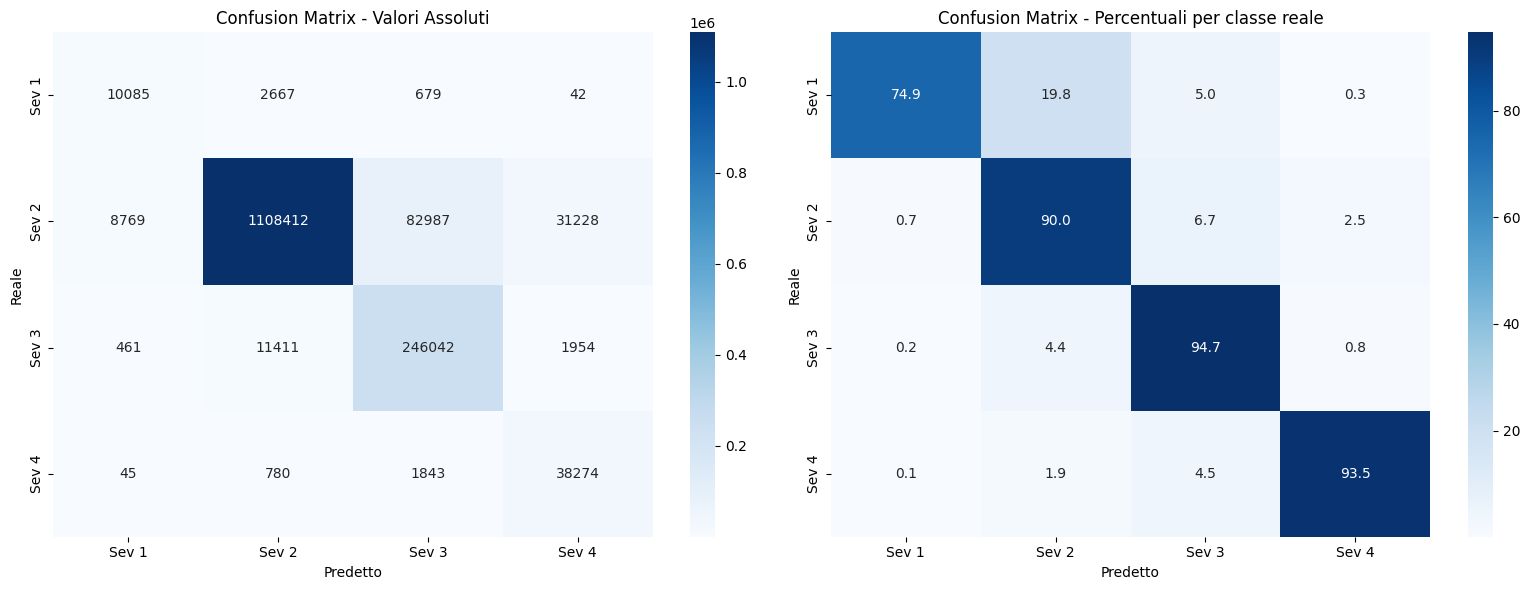


TOP 20 FEATURE IMPORTANCE
            feature  importance
    desc_length_log       79539
   duration_min_log       78307
       Pressure(in)       75263
          Start_Lat       67730
          Start_Lng       64628
            Zipcode       64019
     Temperature(F)       63588
        Humidity(%)       60754
               City       52090
   Distance(mi)_log       47629
Wind_Speed(mph)_log       45963
             County       44532
        Street_Type       34573
              State       27517
           Wind_Cos       22929
          month_sin       22885
          month_cos       22018
           Wind_Sin       20912
        time_of_day       19438
     Visibility(mi)       13348


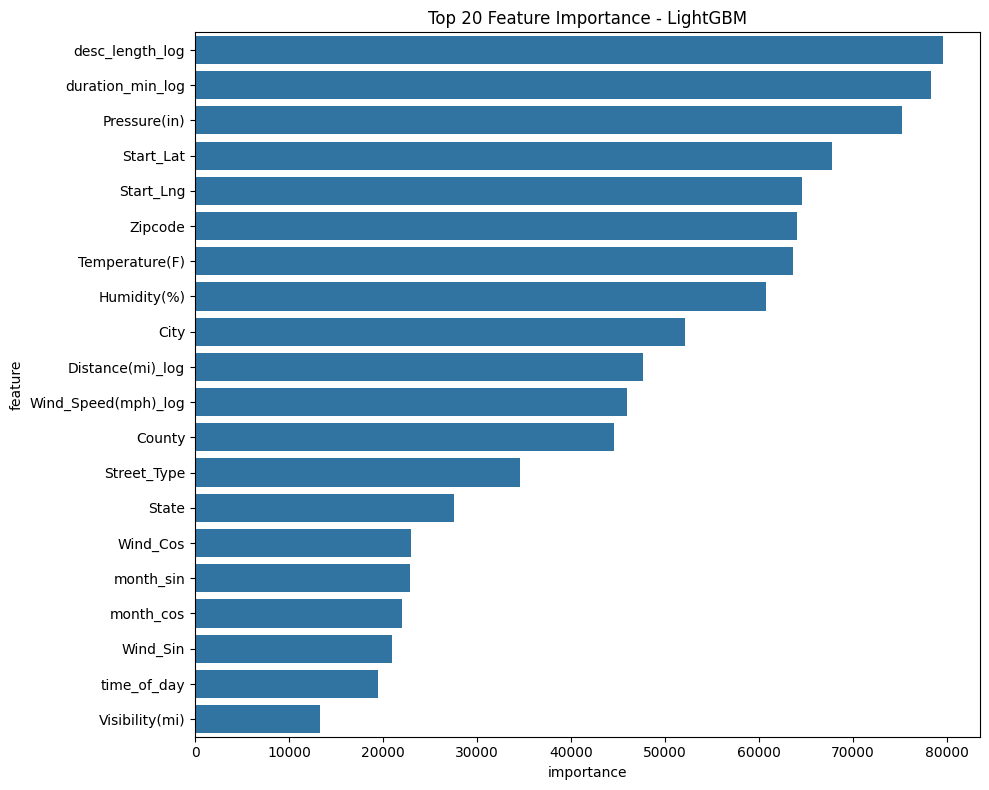

In [11]:
y_pred_list = []
for i in range(0, len(X_test), 100000):
    batch = X_test.iloc[i:i+100000]
    y_pred_list.append(model.predict(batch))
    print(f"Batch {i//100000 + 1}/{math.ceil(len(X_test)/100000)} completato")

y_pred_test = np.concatenate(y_pred_list)

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion Matrix
cm         = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature Importance
print("\n" + "="*60)
print("TOP 20 FEATURE IMPORTANCE")
print("="*60)
feat_imp = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

## MODEL WITH DIFF WEIGHTS

In [36]:
base_weights          = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights_custom = base_weights.copy()
mask_class0           = (y_train == 0).values
mask_class2           = (y_train == 2).values
mask_class3           = (y_train == 3).values
sample_weights_custom[mask_class0] *= 0.065
sample_weights_custom[mask_class2] *= 0.45
sample_weights_custom[mask_class3] *= 0.15

for cls in range(4):
    mask = (y_train == cls).values
    print(f"Classe {cls} (Severity {cls+1}): peso medio = {sample_weights_custom[mask].mean():.3f}")

Classe 0 (Severity 1): peso medio = 1.864
Classe 1 (Severity 2): peso medio = 0.314
Classe 2 (Severity 3): peso medio = 0.669
Classe 3 (Severity 4): peso medio = 1.416


## PARAMETERS

In [37]:
LEARNING_RATE    = 0.01
NUM_LEAVES       = 255
RANDOM_STATE     = 42
SUBSAMPLE        = 0.8
COLSAMPLE_BYTREE = 0.8
REG_ALPHA        = 0.1
REG_LAMBDA       = 0.1

## MODEL

In [38]:
model_1 = lgb.LGBMClassifier(
    n_estimators=10000,
    learning_rate=LEARNING_RATE,
    num_leaves=NUM_LEAVES,
    min_child_samples=50,
    min_child_weight=1e-3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    reg_alpha=REG_ALPHA,
    reg_lambda=REG_LAMBDA
)

## TRAINING

In [ ]:
model_1.fit(
    X_train, y_train,
    sample_weight=sample_weights_custom,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Weather_Group', 'Street_Type']
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's multi_logloss: 0.625896
[20]	valid_0's multi_logloss: 0.555664
[30]	valid_0's multi_logloss: 0.49951
[40]	valid_0's multi_logloss: 0.453485
[50]	valid_0's multi_logloss: 0.417071
[60]	valid_0's multi_logloss: 0.386615
[70]	valid_0's multi_logloss: 0.360694
[80]	valid_0's multi_logloss: 0.339081
[90]	valid_0's multi_logloss: 0.320398
[100]	valid_0's multi_logloss: 0.304808
[110]	valid_0's multi_logloss: 0.291631
[120]	valid_0's multi_logloss: 0.280481
[130]	valid_0's multi_logloss: 0.270906
[140]	valid_0's multi_logloss: 0.262481
[150]	valid_0's multi_logloss: 0.255118
[160]	valid_0's multi_logloss: 0.248748
[170]	valid_0's multi_logloss: 0.243368
[180]	valid_0's multi_logloss: 0.238571
[190]	valid_0's multi_logloss: 0.234259
[200]	valid_0's multi_logloss: 0.230561
[210]	valid_0's multi_logloss: 0.227274
[220]	valid_0's multi_logloss: 0.224408
[230]	valid_0's multi_logloss: 0.221763
[240]	valid_0's multi_loglos

,boosting_type,'gbdt'
,num_leaves,255
,max_depth,-1
,learning_rate,0.01
,n_estimators,10000
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


## EVALUATION

Batch 1/16 completato
Batch 2/16 completato
Batch 3/16 completato
Batch 4/16 completato
Batch 5/16 completato
Batch 6/16 completato
Batch 7/16 completato
Batch 8/16 completato
Batch 9/16 completato
Batch 10/16 completato
Batch 11/16 completato
Batch 12/16 completato
Batch 13/16 completato
Batch 14/16 completato
Batch 15/16 completato
Batch 16/16 completato

CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.68      0.67      0.67     13473
  Severity 2       0.97      0.95      0.96   1231396
  Severity 3       0.84      0.91      0.87    259868
  Severity 4       0.63      0.81      0.71     40942

    accuracy                           0.93   1545679
   macro avg       0.78      0.83      0.80   1545679
weighted avg       0.94      0.93      0.94   1545679



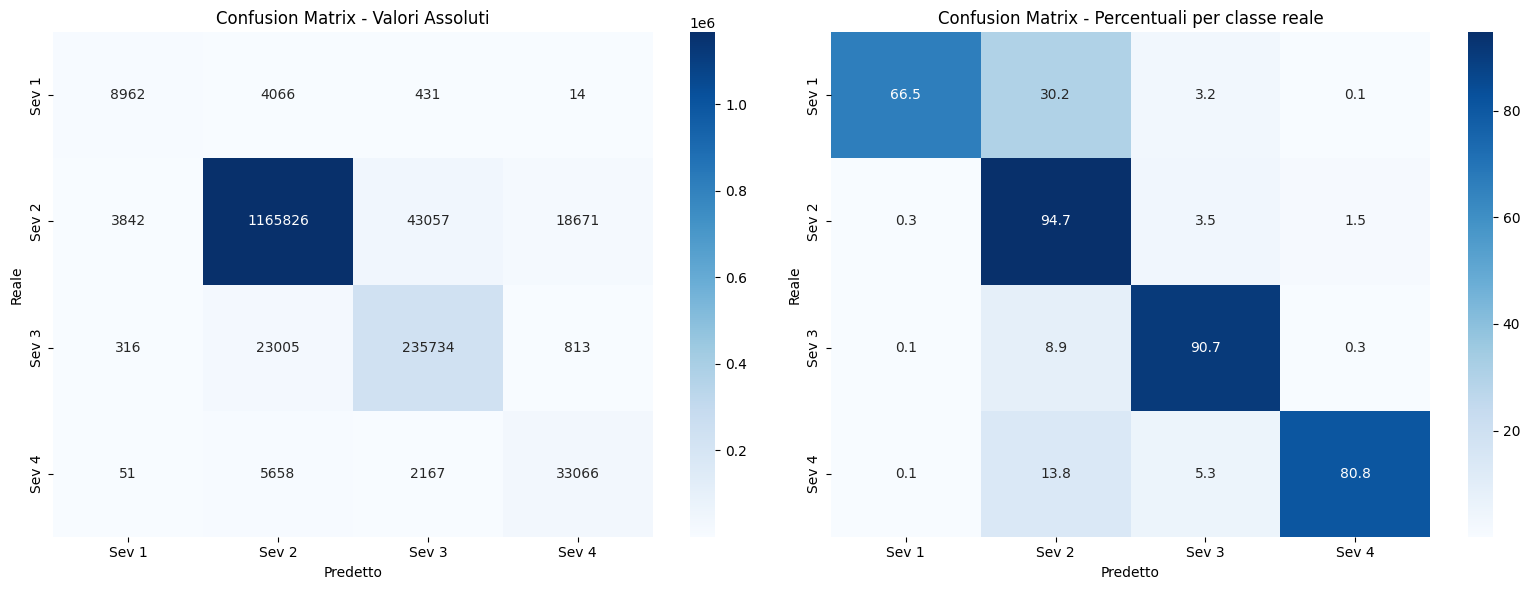


TOP 20 FEATURE IMPORTANCE
            feature  importance
       Pressure(in)      810443
    desc_length_log      804649
   duration_min_log      798007
            Zipcode      705229
     Temperature(F)      695283
        Humidity(%)      683267
          Start_Lat      673944
          Start_Lng      637187
               City      563770
Wind_Speed(mph)_log      494306
   Distance(mi)_log      472999
             County      470001
           Wind_Cos      262544
              State      248776
          month_sin      242006
           Wind_Sin      235309
          month_cos      230871
        Street_Type      207703
        time_of_day      195002
     Visibility(mi)      139430


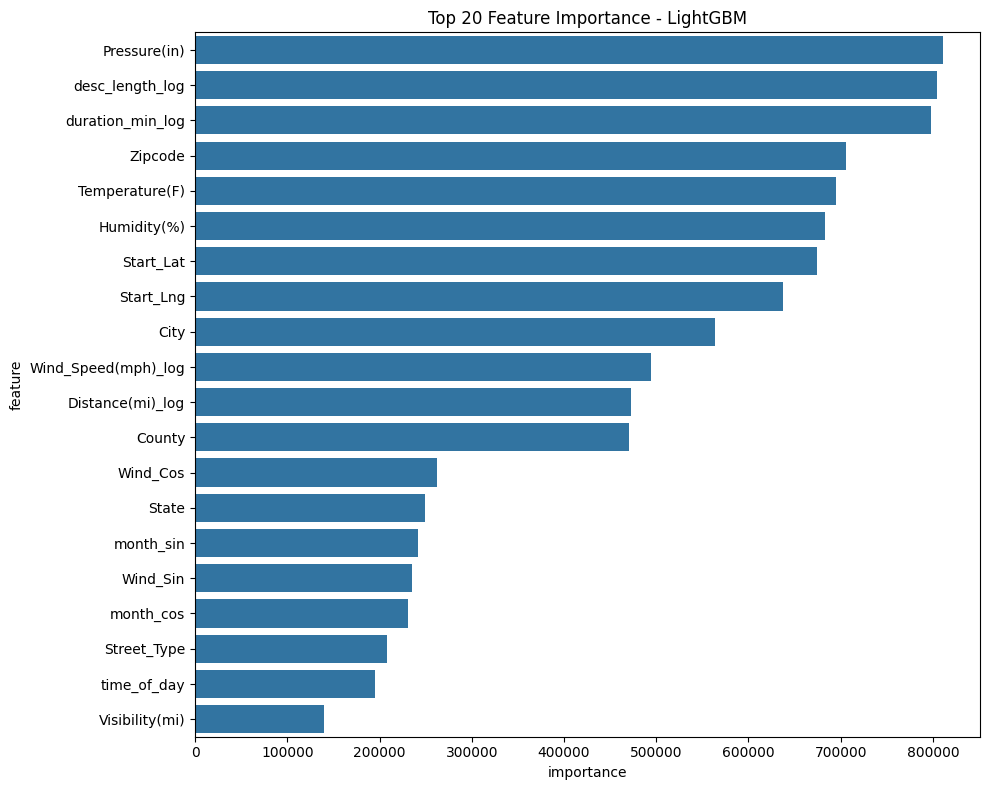

In [40]:
y_pred_list = []
for i in range(0, len(X_test), 100000):
    batch = X_test.iloc[i:i+100000]
    y_pred_list.append(model_1.predict(batch))
    print(f"Batch {i//100000 + 1}/{math.ceil(len(X_test)/100000)} completato")

y_pred_test = np.concatenate(y_pred_list)

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion Matrix
cm         = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature Importance
print("\n" + "="*60)
print("TOP 20 FEATURE IMPORTANCE")
print("="*60)
feat_imp = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': model_1.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

## LAST MODEL

In [7]:
base_weights          = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights_custom = base_weights.copy()
mask_class0           = (y_train == 0).values
mask_class2           = (y_train == 2).values
mask_class3           = (y_train == 3).values
sample_weights_custom[mask_class0] *= 0.065
sample_weights_custom[mask_class2] *= 0.45
sample_weights_custom[mask_class3] *= 0.15

for cls in range(4):
    mask = (y_train == cls).values
    print(f"Classe {cls} (Severity {cls+1}): peso medio = {sample_weights_custom[mask].mean():.3f}")

Classe 0 (Severity 1): peso medio = 1.864
Classe 1 (Severity 2): peso medio = 0.314
Classe 2 (Severity 3): peso medio = 0.669
Classe 3 (Severity 4): peso medio = 1.416


In [8]:
LEARNING_RATE    = 0.01
NUM_LEAVES       = 255
RANDOM_STATE     = 42
SUBSAMPLE        = 0.8
COLSAMPLE_BYTREE = 0.8
REG_ALPHA        = 0.1
REG_LAMBDA       = 0.1

In [9]:
model_3 = lgb.LGBMClassifier(
    n_estimators=20000,
    learning_rate=LEARNING_RATE,
    num_leaves=NUM_LEAVES,
    min_child_samples=50,
    min_child_weight=1e-3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    device='gpu',
    gpu_platform_id=1,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    reg_alpha=REG_ALPHA,
    reg_lambda=REG_LAMBDA
)

In [10]:
model_3.fit(
    X_train, y_train,
    sample_weight=sample_weights_custom,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Weather_Group', 'Street_Type', 'Source', 'Geo_Cluster']
)

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2884
[LightGBM] [Info] Number of data points in the train set: 4946172, number of used features: 42
[LightGBM] [Info] Using requested OpenCL platform 1 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4060 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 24 dense feature groups (113.21 MB) transferred to GPU in 0.158462 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -3.243193
[LightGBM] [Info] Start training from score -0.509825
[LightGBM] [Info] Start training from score -1.308333
[LightGBM] [Info] Start training from score -2.406945
Training until validation scores don't improve for 100 rounds
[10]	train's multi_logloss: 0.850333	val's multi_logloss: 0.625783
[20]	train's multi_logloss: 0.743479	val's multi_log

,boosting_type,'gbdt'
,num_leaves,255
,max_depth,-1
,learning_rate,0.01
,n_estimators,20000
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


Batch 1/16 completato
Batch 2/16 completato
Batch 3/16 completato
Batch 4/16 completato
Batch 5/16 completato
Batch 6/16 completato
Batch 7/16 completato
Batch 8/16 completato
Batch 9/16 completato
Batch 10/16 completato
Batch 11/16 completato
Batch 12/16 completato
Batch 13/16 completato
Batch 14/16 completato
Batch 15/16 completato
Batch 16/16 completato

CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.75      0.63      0.68     13473
  Severity 2       0.97      0.95      0.96   1231396
  Severity 3       0.85      0.90      0.88    259868
  Severity 4       0.65      0.75      0.70     40942

    accuracy                           0.94   1545679
   macro avg       0.80      0.81      0.80   1545679
weighted avg       0.94      0.94      0.94   1545679



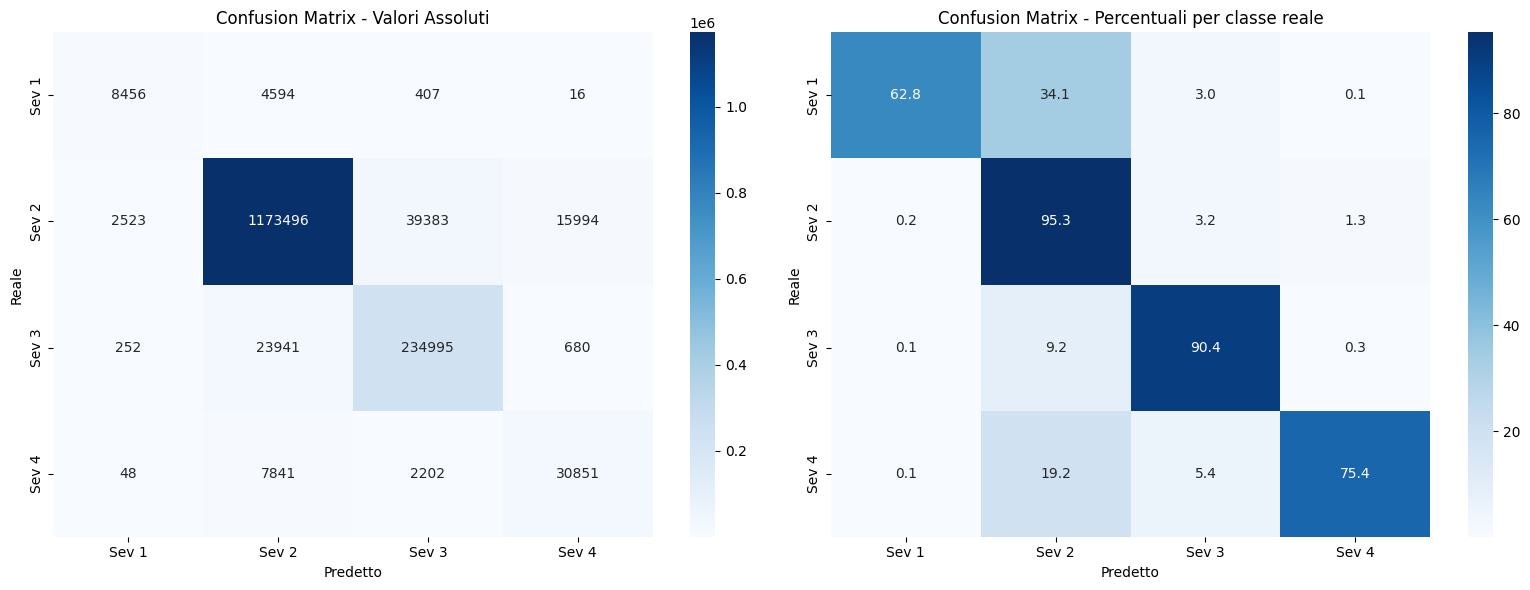


TOP 20 FEATURE IMPORTANCE
            feature  importance
       Pressure(in)     1407136
   duration_min_log     1377786
    desc_length_log     1374700
            Zipcode     1232063
     Temperature(F)     1225458
        Humidity(%)     1220019
          Start_Lat     1092847
          Start_Lng     1012589
               City      969466
Wind_Speed(mph)_log      865367
   Distance(mi)_log      810779
             County      790463
           Wind_Cos      468531
          month_sin      422199
           Wind_Sin      420700
          month_cos      396416
              State      377784
        time_of_day      330174
        Street_Type      289317
     Visibility(mi)      239441


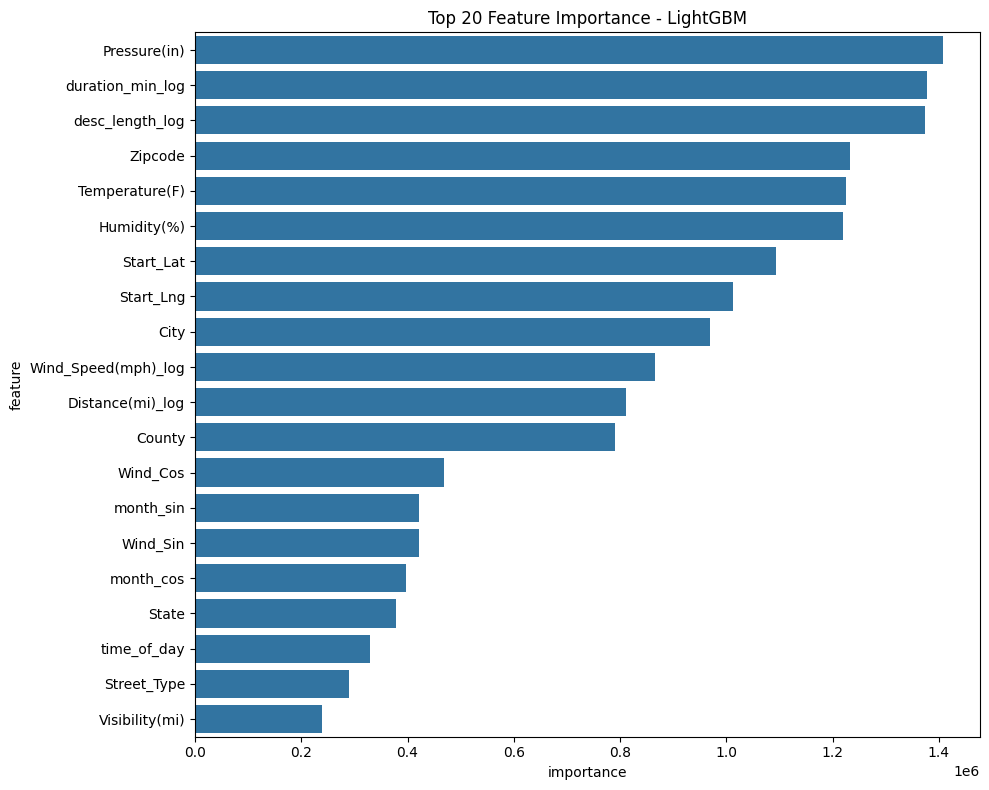

In [12]:
y_pred_list = []
for i in range(0, len(X_test), 100000):
    batch = X_test.iloc[i:i+100000]
    y_pred_list.append(model_3.predict(batch))
    print(f"Batch {i//100000 + 1}/{math.ceil(len(X_test)/100000)} completato")

y_pred_test = np.concatenate(y_pred_list)

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion Matrix
cm         = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature Importance
print("\n" + "="*60)
print("TOP 20 FEATURE IMPORTANCE")
print("="*60)
feat_imp = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': model_3.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

In [11]:
import joblib

# Salva il modello
joblib.dump(model_3, 'lgbm_model_final.pkl')
print("Modello salvato!")

joblib.dump(model_3, 'lgbm_model_final.pkl')
joblib.dump(km,    'kmeans_geo.pkl')

freq_maps = {}
for col in ['City', 'County', 'State', 'Zipcode']:
    freq_maps[col] = X_train[col].value_counts().to_dict()

joblib.dump(freq_maps, 'freq_maps.pkl')

Modello salvato!


['freq_maps.pkl']